<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/06_poredjenje_modela_blagoje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — Poređenje modela (Blagoje)

Uporedna evaluacija sva 4 istrenirana modela (SVM, Random Forest, ResNet18 transfer learning, CNN od nule)
na istom test skupu (844 slike), korišćenjem već sačuvanih modela iz `models/` — bez ponovnog treniranja.

- **Ulaz:** sačuvani modeli (`models/*.joblib`, `models/*.pt`) + `data_split.csv`
- **Test skup:** isti za sve modele (844 slike, `split == 'test'`)
- **Mera:** macro-F1 (primarna), accuracy (dodatna)

### 1. Priprema — kloniranje modela/osobina i skidanje slika

In [ ]:
import os

# 1) repo: modeli + features_hog_color.npy + data_split.csv
if not os.path.exists('features_hog_color.npy'):
    !git clone -q https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification.git repo
    !cp repo/features_hog_color.npy repo/data_split.csv .
    !cp -r repo/models .

# 2) slike (trebaju za CNN i transfer) sa Kaggle-a
if not os.path.exists('data'):
    from google.colab import userdata
    os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
    !pip install -U kaggle -q
    !kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
    !unzip -q tom-and-jerry-image-classification.zip -d data/

print('modeli:', os.listdir('models'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 3.1 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:02<00:00, 196MB/s]

modeli: ['svm_final.joblib', 'rf_final.joblib', 'cnn_scratch.pt', 'resnet18_transfer.pt', 'svm_scaler.joblib']


### 2. Podela podataka i test skup (osobine za klasične modele)

In [ ]:
import glob, numpy as np, pandas as pd

# mapa ime_fajla -> putanja na disku, pa kolona filepath
disk = {os.path.basename(p): p for p in glob.glob('data/**/*.jpg', recursive=True)}
split_df = pd.read_csv('data_split.csv')
split_df['filepath'] = split_df['filename'].map(disk)
assert split_df['filepath'].notna().all(), 'neke slike nisu nadjene'

# klasične osobine (HOG+boje) i TEST maska
X = np.load('features_hog_color.npy')
test_mask = split_df['split'].values == 'test'
X_test  = X[test_mask]
y_test  = split_df['class'].values[test_mask]              # imena klasa (stringovi)
test_df = split_df[split_df['split'] == 'test'].reset_index(drop=True)

CLASSES = ['tom', 'jerry', 'both', 'neither']              # redosled za tabelu/izveštaj
print('X_test:', X_test.shape, '| test slika:', len(test_df))

X_test: (844, 1860) | test slika: 844


### 3. Klasični modeli — Random Forest i SVM

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

def evaluate(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} ===  Accuracy: {acc:.4f}   Macro-F1: {mf1:.4f}")
    print(classification_report(y_true, y_pred, labels=CLASSES))
    return {'model': model_name, 'accuracy': acc, 'macro_f1': mf1}

In [ ]:
# Random Forest — radi nad osobinama, BEZ skaliranja
rf = joblib.load('models/rf_final.joblib')
rez_rf = evaluate(y_test, rf.predict(X_test), 'Random Forest (klasičan)')

# SVM — radi nad SKALIRANIM osobinama (isti scaler kojim je treniran)
svm    = joblib.load('models/svm_final.joblib')
scaler = joblib.load('models/svm_scaler.joblib')
rez_svm = evaluate(y_test, svm.predict(scaler.transform(X_test)), 'SVM RBF (klasičan)')

=== Random Forest (klasičan) ===  Accuracy: 0.5047   Macro-F1: 0.4223
              precision    recall  f1-score   support

         tom       0.51      0.83      0.63       289
       jerry       0.64      0.24      0.35       194
        both       1.00      0.13      0.23       131
     neither       0.43      0.53      0.48       230

    accuracy                           0.50       844
   macro avg       0.65      0.43      0.42       844
weighted avg       0.60      0.50      0.46       844

=== SVM RBF (klasičan) ===  Accuracy: 0.4668   Macro-F1: 0.4458
              precision    recall  f1-score   support

         tom       0.53      0.52      0.53       289
       jerry       0.45      0.29      0.35       194
        both       0.58      0.32      0.41       131
     neither       0.40      0.63      0.49       230

    accuracy                           0.47       844
   macro avg       0.49      0.44      0.45       844
weighted avg       0.48      0.47      0.46       8

### 4. Duboki modeli — CNN i transfer learning

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class ImgDS(Dataset):                      # cita slike test skupa po redu iz test_df
    def __init__(self, df, tf):
        self.paths = df['filepath'].values
        self.tf = tf
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        return self.tf(Image.open(self.paths[i]).convert('RGB'))

def predict_deep(model, tf, idx_to_class):
    loader = DataLoader(ImgDS(test_df, tf), batch_size=64, shuffle=False, num_workers=2)
    model.eval(); preds = []
    with torch.no_grad():
        for xb in loader:
            preds.extend(model(xb.to(device)).argmax(1).cpu().tolist())
    return [idx_to_class[i] for i in preds]   # brojeve -> imena klasa (mapping svakog modela!)

In [ ]:
IMG_SIZE = 64
class SmallCNN(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2); self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * (IMG_SIZE//8) * (IMG_SIZE//8), 128)
        self.fc2 = nn.Linear(128, n)
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

cnn = SmallCNN(4).to(device)
cnn.load_state_dict(torch.load('models/cnn_scratch.pt', map_location=device))

cnn_tf  = T.Compose([T.Resize((64, 64)), T.ToTensor(), T.Normalize([0.5]*3, [0.5]*3)])
cnn_idx = {0: 'both', 1: 'jerry', 2: 'neither', 3: 'tom'}   # TVOJ (sorted) redosled
rez_cnn = evaluate(y_test, predict_deep(cnn, cnn_tf, cnn_idx), 'CNN od nule (duboki)')

=== CNN od nule (duboki) ===  Accuracy: 0.5900   Macro-F1: 0.5537
              precision    recall  f1-score   support

         tom       0.80      0.71      0.75       289
       jerry       0.49      0.44      0.46       194
        both       0.39      0.39      0.39       131
     neither       0.56      0.68      0.61       230

    accuracy                           0.59       844
   macro avg       0.56      0.55      0.55       844
weighted avg       0.60      0.59      0.59       844



In [ ]:
from torchvision import models
res = models.resnet18(weights=None)                       # samo arhitektura
res.fc = nn.Linear(res.fc.in_features, 4)                 # 4 klase kao kod Ike
res.load_state_dict(torch.load('models/resnet18_transfer.pt', map_location=device))
res = res.to(device)

res_tf  = T.Compose([T.Resize((224, 224)), T.ToTensor(),
                     T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])  # ImageNet
res_idx = {0: 'tom', 1: 'jerry', 2: 'both', 3: 'neither'}  # IKIN redosled (drugačiji!)
rez_transfer = evaluate(y_test, predict_deep(res, res_tf, res_idx), 'Transfer ResNet18 (duboki)')

=== Transfer ResNet18 (duboki) ===  Accuracy: 0.8341   Macro-F1: 0.7940
              precision    recall  f1-score   support

         tom       0.80      0.93      0.86       289
       jerry       0.84      0.89      0.86       194
        both       0.84      0.43      0.57       131
     neither       0.88      0.89      0.88       230

    accuracy                           0.83       844
   macro avg       0.84      0.79      0.79       844
weighted avg       0.84      0.83      0.82       844



### 5. Uporedna tabela i zaključak

In [ ]:
import pandas as pd

svi = [rez_transfer, rez_cnn, rez_svm, rez_rf]
tabela = pd.DataFrame(svi).sort_values('macro_f1', ascending=False).reset_index(drop=True)
tabela

,model,accuracy,macro_f1
0,Transfer ResNet18 (duboki),0.834123,0.794030
1,CNN od nule (duboki),0.590047,0.553715
2,SVM RBF (klasičan),0.466825,0.445754
3,Random Forest (klasičan),0.504739,0.422251


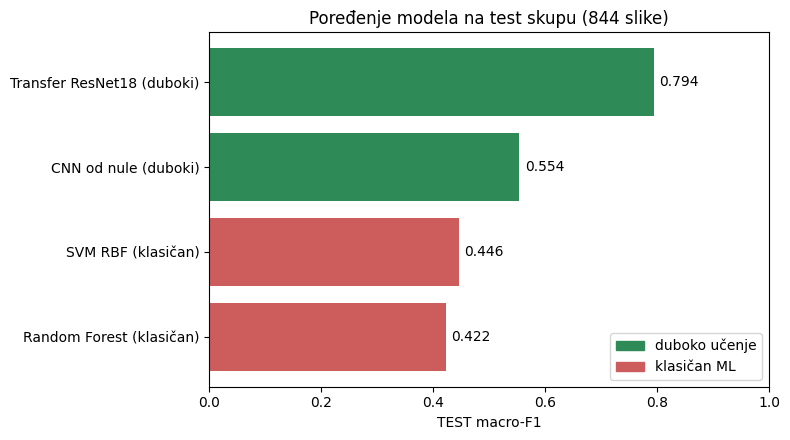

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

t = tabela.sort_values('macro_f1')                        # rastuce -> najbolji na vrhu
boje = ['seagreen' if '(duboki)' in m else 'indianred' for m in t['model']]

plt.figure(figsize=(8, 4.5))
plt.barh(t['model'], t['macro_f1'], color=boje)
for i, f in enumerate(t['macro_f1']):
    plt.text(f + 0.01, i, f'{f:.3f}', va='center')
plt.xlim(0, 1); plt.xlabel('TEST macro-F1')
plt.title('Poređenje modela na test skupu (844 slike)')
plt.legend(handles=[Patch(color='seagreen', label='duboko učenje'),
                    Patch(color='indianred', label='klasičan ML')])
plt.tight_layout(); plt.show()

## Zaključak

- Poredak po TEST macro-F1: **Transfer ResNet18 (0.79) > CNN od nule (0.55) > SVM (0.45) > Random Forest (0.42).**
- **Duboko učenje ubedljivo nadmašuje klasične modele.** Transfer learning je najbolji jer
  koristi težine pretrenirane na milionima slika (ImageNet), pa mu treba malo podataka da se
  prilagodi Tomu i Džeriju.
- **CNN od nule** (0.55) pobeđuje klasične, ali je slabiji od transfera — uči isključivo iz
  ~3800 naših slika.
- **Klasični modeli (SVM, RF)** su na ~0.42–0.45 — to je plafon ručno dizajniranih osobina (HOG + boje).
- Najteže klase su svima **`both`** i **`jerry`**; transfer i njih rešava znatno bolje.